<a href="https://colab.research.google.com/github/valluripavanayyappa-code/-CodeAlpha_CreditScoringModel/blob/main/Credit%20Scoring%20Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("credit_scoring_dataset.csv")

print(df.head())

   customer_id  age  annual_income  employment_years  num_credit_accounts  \
0            1   61          80174               7.3                    3   
1            2   62          48719              13.5                    5   
2            3   43          26152              16.8                    9   
3            4   26          79662               2.3                    8   
4            5   38          83527              10.0                   11   

   credit_utilization_pct  num_late_payments  num_hard_inquiries  total_debt  \
0                    73.0                  1                   3       10433   
1                    80.0                  0                   3       83777   
2                    13.0                  4                   0       35181   
3                    63.0                  0                   0       25141   
4                    33.0                  2                   0       98616   

   debt_to_income_ratio  loan_amount_requested  loan_ten

In [6]:
df = df.drop("customer_id", axis=1)

In [7]:
encoder = LabelEncoder()

df["education_level"] = encoder.fit_transform(df["education_level"])
df["home_ownership"] = encoder.fit_transform(df["home_ownership"])

In [8]:
# Savings-to-Income Ratio
df["savings_income_ratio"] = df["savings_balance"] / df["annual_income"]

# Debt per Credit Account
df["debt_per_account"] = (
    df["total_debt"] / (df["num_credit_accounts"] + 1)
)

# Loan-to-Income Ratio
df["loan_income_ratio"] = (
    df["loan_amount_requested"] / df["annual_income"]
)

In [9]:
X = df.drop("creditworthy", axis=1)
y = df["creditworthy"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [12]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [13]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.845
Precision: 0.8604651162790697
Recall   : 0.5967741935483871
F1 Score : 0.7047619047619048
ROC-AUC  : 0.9467625058438522


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.96      0.89       138
           1       0.86      0.60      0.70        62

    accuracy                           0.84       200
   macro avg       0.85      0.78      0.80       200
weighted avg       0.85      0.84      0.84       200



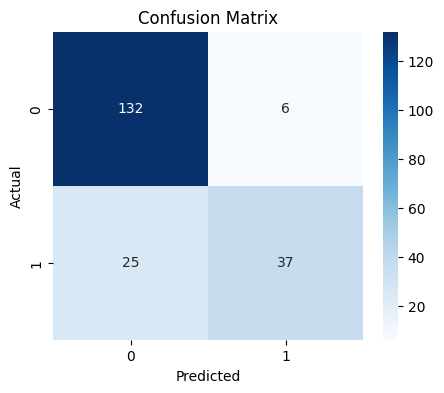

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                   Feature  Importance
2         employment_years    0.164324
5        num_late_payments    0.164272
8     debt_to_income_ratio    0.107940
1            annual_income    0.081410
16        debt_per_account    0.063307
11         savings_balance    0.059022
0                      age    0.058670
7               total_debt    0.053953
4   credit_utilization_pct    0.051106
15    savings_income_ratio    0.042220
3      num_credit_accounts    0.029152
9    loan_amount_requested    0.023048
6       num_hard_inquiries    0.022892
17       loan_income_ratio    0.021831
13         education_level    0.017683
10      loan_tenure_months    0.016335
12          num_dependents    0.013332
14          home_ownership    0.009502


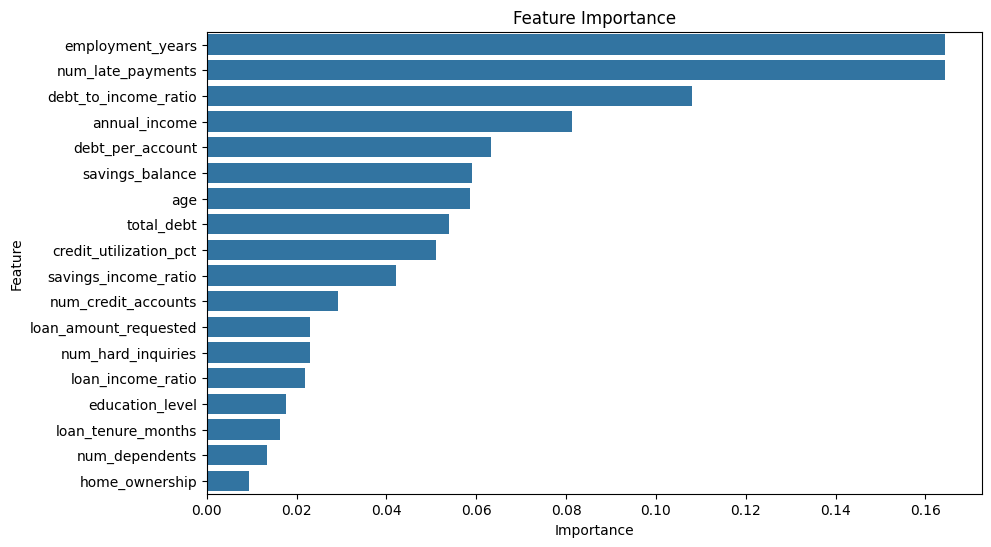

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()